In [6]:
#COSC 522 UTK
#Project 2
#Student Name: Dilen Patel

In [7]:
#load in data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)


In [8]:
## Load the dataset. Make Load the datasetMake sure `ndtv_data_final.csv` is in the same folder as this notebook before running.
dataset = pd.read_csv("ndtv_data_final.csv")
print(dataset.columns)

Index(['Unnamed: 0', 'Name', 'Brand', 'Model', 'Battery capacity (mAh)',
       'Screen size (inches)', 'Touchscreen', 'Resolution x', 'Resolution y',
       'Processor', 'RAM (MB)', 'Internal storage (GB)', 'Rear camera',
       'Front camera', 'Operating system', 'Wi-Fi', 'Bluetooth', 'GPS',
       'Number of SIMs', '3G', '4G/ LTE', 'Price'],
      dtype='object')


In [9]:
dataset.tail()

,Unnamed: 0,Name,Brand,Model,Battery capacity (mAh),Screen size (inches),Touchscreen,Resolution x,Resolution y,Processor,...,Rear camera,Front camera,Operating system,Wi-Fi,Bluetooth,GPS,Number of SIMs,3G,4G/ LTE,Price
1354,1354,Intex Aqua A2,Intex,Aqua A2,1500,4.0,Yes,480,800,4,...,5.0,0.3,Android,Yes,Yes,Yes,2,Yes,No,2599
1355,1355,Videocon Infinium Z51 Nova+,Videocon,Infinium Z51 Nova+,2000,5.0,Yes,480,854,4,...,8.0,5.0,Android,Yes,Yes,Yes,2,Yes,No,2940
1356,1356,Intex Aqua Y4,Intex,Aqua Y4,1700,4.5,Yes,480,854,2,...,5.0,2.0,Android,Yes,Yes,No,2,Yes,No,2999
1357,1357,iBall Andi4 B20,iBall,Andi4 B20,1250,4.0,Yes,480,800,1,...,2.0,0.3,Android,Yes,Yes,Yes,2,Yes,No,2498
1358,1358,iBall Andi Avonte 5,iBall,Andi Avonte 5,2150,5.0,Yes,480,854,4,...,8.0,0.0,Android,Yes,Yes,Yes,2,Yes,No,3999


In [10]:
features = [
    "Brand",
    "Operating system",
    "Battery capacity (mAh)",
    "Screen size (inches)",
    "Resolution x",
    "Resolution y",
    "RAM (MB)",
    "Internal storage (GB)",
    "Rear camera",
    "Front camera"
]

target = "Price"

X = dataset[features].copy()
y = dataset[target].copy()

print("Feature columns selected:", features)
print("Target column:", target)

Feature columns selected: ['Brand', 'Operating system', 'Battery capacity (mAh)', 'Screen size (inches)', 'Resolution x', 'Resolution y', 'RAM (MB)', 'Internal storage (GB)', 'Rear camera', 'Front camera']
Target column: Price


In [11]:
X = pd.get_dummies(X, columns=["Brand", "Operating system"])

print("Encoded feature matrix shape:", X.shape)
X.head()

Encoded feature matrix shape: (1359, 91)


,Battery capacity (mAh),Screen size (inches),Resolution x,Resolution y,RAM (MB),Internal storage (GB),Rear camera,Front camera,Brand_10.or,Brand_Acer,...,Brand_iBall,Brand_iVoomi,Brand_mPhone,Operating system_Android,Operating system_BlackBerry,Operating system_Cyanogen,Operating system_Sailfish,Operating system_Tizen,Operating system_Windows,Operating system_iOS
0,4085,6.67,1440,3120,12000,256.0,48.0,16.0,False,False,...,False,False,False,True,False,False,False,False,False,False
1,4000,6.50,1080,2400,6000,64.0,64.0,16.0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,3969,6.50,1242,2688,4000,64.0,12.0,12.0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,3110,6.10,828,1792,4000,64.0,12.0,12.0,False,False,...,False,False,False,False,False,False,False,False,False,True
4,4000,6.40,1080,2340,6000,128.0,12.0,32.0,False,False,...,False,False,False,True,False,False,False,False,False,False


In [12]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.17647058823529413,
    random_state=42
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 951
Validation set size: 204
Test set size: 204


In [13]:
##I used standard scalar so that the features can be on a similar scale.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (951, 91)


In [14]:
overtrained_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1)
])

overtrained_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

overtrained_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        23,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,561 (510.00 KB)

 Trainable params: 130,561 (510.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_over = overtrained_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 306260000.0000 - mae: 11390.0176 - val_loss: 257626992.0000 - val_mae: 10657.9678
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 272609184.0000 - mae: 10250.4561 - val_loss: 160416624.0000 - val_mae: 7078.0586
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 117458272.0000 - mae: 5791.7939 - val_loss: 71429448.0000 - val_mae: 5395.7710
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 83583376.0000 - mae: 4601.8696 - val_loss: 59812300.0000 - val_mae: 4702.0449
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 73429024.0000 - mae: 4410.5562 - val_loss: 55303576.0000 - val_mae: 4371.9585
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 68408648.0000 - mae: 4165.0918 - val_loss: 53795424.0000 - val_mae: 4437.2642
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 65911172.0000 - mae: 4222.3735 - val_loss: 49692488.0000 - val_mae: 4107.8472
Epoch 8/200
30/30 ━━━━━━━━━━━━

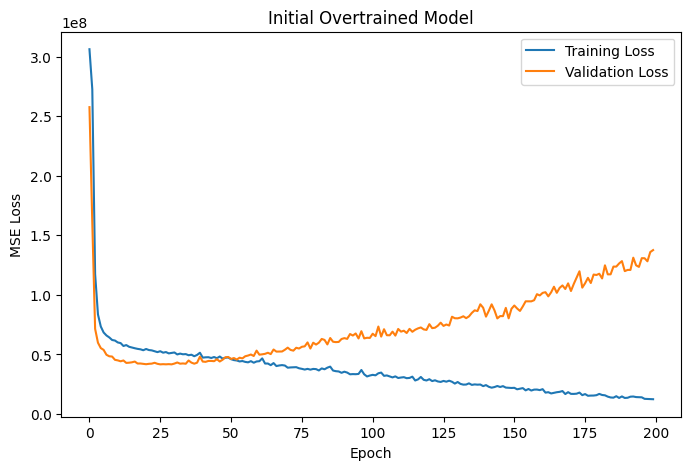

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_over.history["loss"], label="Training Loss")
plt.plot(history_over.history["val_loss"], label="Validation Loss")
plt.title("Initial Overtrained Model")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [17]:
##This model uses early stopping so the training stops once validation stops improving

final_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

final_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,145 (86.50 KB)

 Trainable params: 22,145 (86.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_final = final_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 307087296.0000 - mae: 11419.8379 - val_loss: 261997168.0000 - val_mae: 10825.9180
Epoch 2/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 306789728.0000 - mae: 11409.1514 - val_loss: 261383088.0000 - val_mae: 10804.2373
Epoch 3/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 305369056.0000 - mae: 11365.7871 - val_loss: 258647024.0000 - val_mae: 10721.6328
Epoch 4/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 300426464.0000 - mae: 11217.6709 - val_loss: 249652144.0000 - val_mae: 10472.2500
Epoch 5/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 285099584.0000 - mae: 10819.7393 - val_loss: 227859168.0000 - val_mae: 9874.3926
Epoch 6/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 254587792.0000 - mae: 9982.4551 - val_loss: 188974224.0000 - val_mae: 8728.0166
Epoch 7/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 208117472.0000 - mae: 8468.3877 - val_loss: 137370944.0000 - val_mae: 6911.0464
Epoch 8/300
30/30

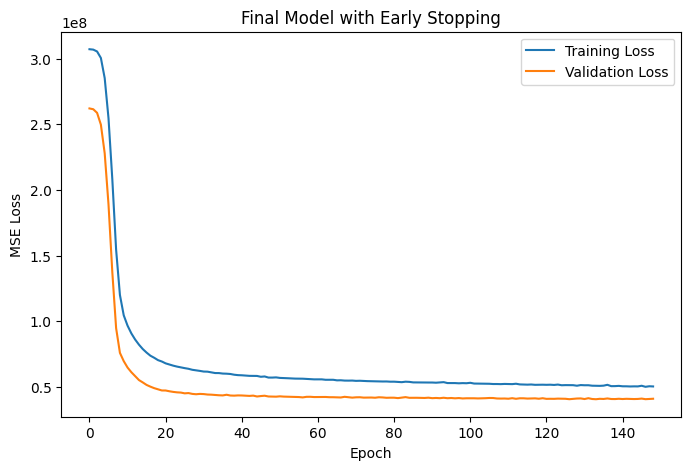

Epochs actually run: 149
Best epoch by validation loss: 134


In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history_final.history["loss"], label="Training Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")
plt.title("Final Model with Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

print("Epochs actually run:", len(history_final.history["loss"]))
print("Best epoch by validation loss:", np.argmin(history_final.history["val_loss"]) + 1)

In [20]:
predictions = final_model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R^2:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Test MAE: 4119.7431640625
Test RMSE: 7739.305136767771
Test R^2: 0.8060085773468018
